# Minibatches, expectation, and gradient noise

CPU companion; no accelerator is required. TPU execution not validated.

- Explain an unbiased minibatch gradient and verify how sampling and reduction affect its variance.
- Define the population before estimating it
- Make the independence assumption explicit
- Weight unequal batches by example count
- Separate noise, replay and progress

A minibatch may suggest a different update from the full dataset. Is it wrong, or is it a noisy estimate? We will enumerate every possible tiny batch so expectation and variance become quantities you can inspect rather than claims you have to trust.

## The idea

A minibatch gradient estimates the full-data gradient using fewer examples. Its noise depends on the sampling scheme and batch size. When combining batches, the denominator must still represent the population you intend to average over.

## Average examples rather than batch averages

Suppose one batch has two examples with mean loss $1$, and another has one example with loss $4$. Averaging batch means gives $2.5$. The mean over all three examples is $(2+4)/3=2$. The first calculation gave the small batch too much weight.

Carry loss sums and example counts through aggregation, then divide once. For token losses, carry valid-token counts instead: examples and tokens are different denominators when lengths vary. The same weighting issue appears when combining gradients across devices.

The variance plot illustrates the benefit of averaging under its stated sampling assumptions. Correlated examples, sampling without replacement, and nonuniform sampling can change the relationship. Batch size alone does not fully describe the estimator.

### Pause and reason

Why might doubling batch size fail to halve observed gradient variance?

<details><summary>Compare your reasoning</summary>

The usual inverse-size relationship assumes a particular sampling model, often independent samples. Correlation, finite-population effects, changing parameters or too few repeated measurements can alter the observed ratio.

</details>

## Define the population before estimating it

Use the per-example loss $\ell(w,y)=\tfrac12(w-y)^2$ with targets $(1,2,3,4)$. At $w=0$, the per-example gradients are $(-1,-2,-3,-4)$. Their mean is $-2.5$, and their population variance is $1.25$: average the squared deviations from the mean, dividing by $4$. This finite training dataset is the population for our sampling experiment, not the population of all future data.

$$
g=\frac1n\sum_{i=1}^n g_i,\qquad \operatorname{Var}(g_i)=\frac1n\sum_{i=1}^n(g_i-g)^2
$$

## Make the independence assumption explicit

Draw $B$ examples independently and uniformly with replacement, where $B$ is the batch size. Repeated examples are allowed. The batch gradient $\hat g$ has expectation $g$ and variance $\operatorname{Var}(g_i)/B$. For $B=2$, enumerate all $16$ ordered pairs. The batch variance is $0.625$. Sampling without replacement follows a different variance formula; correlated samples can reduce the benefit of averaging.

$$
\mathbb{E}[\hat g]=g,\qquad \operatorname{Var}(\hat g)=\frac{\operatorname{Var}(g_i)}{B}
$$

## Weight unequal batches by example count

A batch mean over three examples and a batch mean over one example should not receive equal weight when reconstructing the dataset mean. Our first three gradients average to $-2$, while the last is $-4$. Averaging those means gives $-3$, which is wrong. Weighting by counts gives $(3(-2)+1(-4))/4=-2.5$. The same issue appears when accumulating gradients or aggregating metrics across devices.

## Separate noise, replay and progress

A random key records a reproducible sampling choice; reusing it repeats that choice. Split keys for fresh batches. An individual minibatch update can worsen the full loss even though its gradient is unbiased at the current parameters. Log full or held-out evaluation at defined intervals instead of expecting a monotone minibatch curve. Unbiasedness alone does not prove convergence, and changing batch size can change both compute cost and optimization behavior.

## Compute per-example gradients

Create main.py. Keep the parameter fixed while measuring the sampling distribution.

In [1]:
import jax
import jax.numpy as jnp
y = jnp.array([1.0, 2.0, 3.0, 4.0])
w = jnp.array(0.0)

def example_loss(w, y):
    return 0.5 * (w - y) ** 2
per = jax.vmap(jax.grad(example_loss), in_axes=(None, 0))(w, y)
full = jax.grad(lambda w: jnp.mean(jax.vmap(example_loss, in_axes=(None, 0))(w, y)))(w)
assert jnp.allclose(per, jnp.array([-1.0, -2.0, -3.0, -4.0]))
assert jnp.allclose(full, -2.5)

Each example supplies a slope; the dataset objective uses their mean.

## Enumerate every pair

Append the exact with-replacement distribution. No random simulation is needed for this check.

In [2]:
pairs = (per[:, None] + per[None, :]) / 2
assert pairs.shape == (4, 4)
assert jnp.allclose(jnp.mean(pairs), full)
assert jnp.allclose(jnp.var(per), 1.25)
assert jnp.allclose(jnp.var(pairs), 0.625)

All ordered pairs are equally likely under independent uniform draws.

## Sample and replay one batch

Append a PRNG example and run python main.py.

In [3]:
key = jax.random.key(7)
indices = jax.random.choice(key, 4, shape=(2,), replace=True)
replay = jax.random.choice(key, 4, shape=(2,), replace=True)
assert jnp.array_equal(indices, replay)
print('full gradient / single variance / pair variance:', full, jnp.var(per), jnp.var(pairs))
print('sample indices / sample gradient:', indices, jnp.mean(per[indices]))

full gradient / single variance / pair variance: -2.5 1.25 0.625
sample indices / sample gradient: [3 2] -3.5


Replay checks reproducibility. One sample does not estimate the full sampling distribution.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
y = jnp.array([1.0, 2.0, 3.0, 4.0])
w = jnp.array(0.0)

def example_loss(w, y):
    return 0.5 * (w - y) ** 2
per = jax.vmap(jax.grad(example_loss), in_axes=(None, 0))(w, y)
full = jax.grad(lambda w: jnp.mean(jax.vmap(example_loss, in_axes=(None, 0))(w, y)))(w)
assert jnp.allclose(per, jnp.array([-1.0, -2.0, -3.0, -4.0]))
assert jnp.allclose(full, -2.5)

pairs = (per[:, None] + per[None, :]) / 2
assert pairs.shape == (4, 4)
assert jnp.allclose(jnp.mean(pairs), full)
assert jnp.allclose(jnp.var(per), 1.25)
assert jnp.allclose(jnp.var(pairs), 0.625)

key = jax.random.key(7)
indices = jax.random.choice(key, 4, shape=(2,), replace=True)
replay = jax.random.choice(key, 4, shape=(2,), replace=True)
assert jnp.array_equal(indices, replay)
print('full gradient / single variance / pair variance:', full, jnp.var(per), jnp.var(pairs))
print('sample indices / sample gradient:', indices, jnp.mean(per[indices]))

full gradient / single variance / pair variance: -2.5 1.25 0.625
sample indices / sample gradient: [3 2] -3.5


Expected: Full gradient $-2.5$; variances $1.25$ for one example and $0.625$ for two independent draws.

## Averaging independent gradients reduces variance

Predict: How much variance remains when the batch grows from $1$ to $2$?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
triples = (per[:, None, None] + per[None, :, None] + per[None, None, :]) / 3
visual_data = {'kind': 'bar', 'labels': ['batch 1', 'batch 2', 'batch 3'], 'ylabel': 'gradient variance', 'series': [{'label': 'exact enumeration', 'y': [float(jnp.var(per)), float(jnp.var(pairs)), float(jnp.var(triples))]}]}

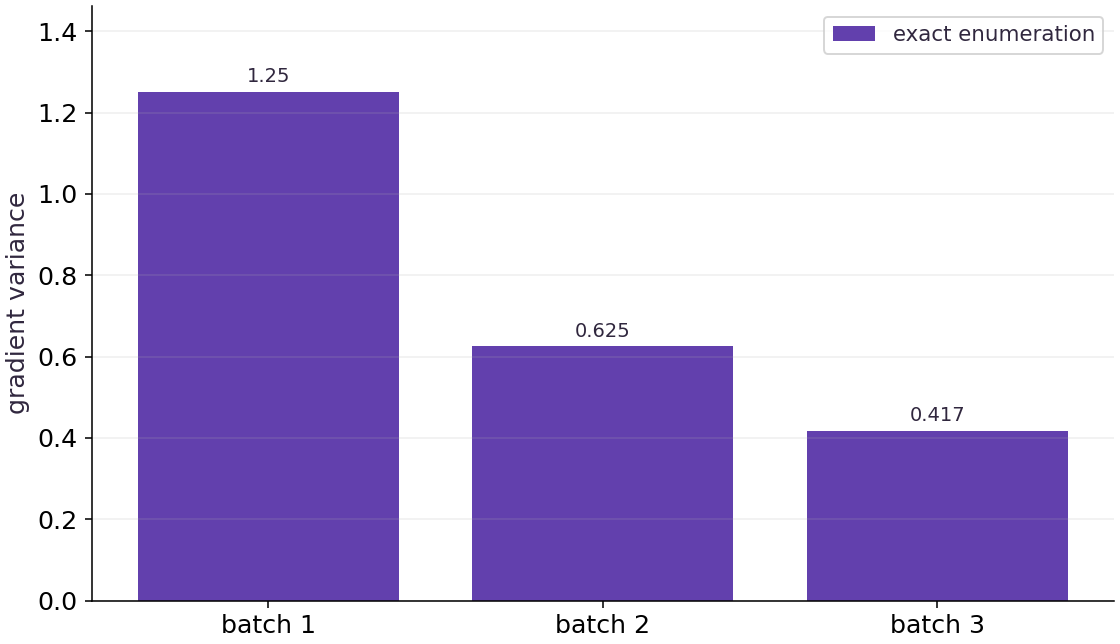

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories are batch sizes $1$, $2$, and $3$. The vertical axis is the variance of the estimated gradient at one fixed weight. The bar heights are $1.25$, $0.625$, and approximately $0.417$, respectively.

Doubling the batch size from $1$ to $2$ halves the variance. Tripling it divides the variance by $3$. These are exact enumerations of the possible sampled batches in this small example, rather than noisy estimates from a handful of trials.

### Connect it to the computation

Each batch averages independent, uniformly sampled per-example gradients with replacement. Under those assumptions, the variance of the average is the single-example variance divided by batch size. Its expected gradient remains $-2.5$ for all three sizes; the estimate becomes less variable without changing its mean.

The bar heights are squared gradient units, not loss or gradient magnitude. A shorter bar does not mean a smaller learning rate or a faster overall training run. Sampling without replacement, correlated examples, and changing parameters require a different variance analysis.

## Combine unequal batches

Predict: Will an unweighted mean of the two batch means recover the full gradient?

In [7]:
first = jnp.mean(per[:3])
last = jnp.mean(per[3:])
wrong = (first + last) / 2
correct = (3 * first + last) / 4
assert jnp.allclose(wrong, -3.0)
assert jnp.allclose(correct, full)

Expected: The unweighted result is $-3$, while count weighting recovers $-2.5$.

Batch means require example-count weights when batch sizes differ.

## Take a noisy step at the full optimum

Predict: At the full-data optimum $w=2.5$, does a step toward target $1$ improve the full loss?

In [8]:
full_loss = lambda w: jnp.mean(0.5 * (w - y) ** 2)
optimum = jnp.array(2.5)
noisy = optimum - 0.1 * jax.grad(example_loss)(optimum, y[0])
assert jnp.allclose(jax.grad(full_loss)(optimum), 0.0)
assert full_loss(noisy) > full_loss(optimum)

Expected: The single-example step increases the full-data loss.

A noisy gradient may point away from the full optimum on a particular draw.

## Your exercise

Enumerate all $64$ ordered batches of size $3$. Check their mean and variance against the independent-sampling formula.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
triples = (per[:, None, None] + per[None, :, None] + per[None, None, :]) / 3
assert triples.size == 64
assert jnp.allclose(jnp.mean(triples), full, atol=1e-06)
assert jnp.allclose(jnp.var(triples), 1.25 / 3, atol=1e-06)

## Accumulate before updating · Transfer / diagnosis

At the same fixed $w$, accumulate gradients from microbatches of sizes $3$ and $1$. Verify that one update matches the full-batch update.

Hint: Do not update parameters between microbatches. Weight each mean by its sample count.

In [11]:
# Write your attempt here.

## Reference reasoning

Exact accumulation matches the full mean gradient only when all microbatches use the same parameters and the reduction is correct.

In [12]:
g1 = jax.grad(lambda z: jnp.mean(0.5 * (z - y[:3]) ** 2))(w)
g2 = jax.grad(lambda z: jnp.mean(0.5 * (z - y[3:]) ** 2))(w)
accumulated = (3 * g1 + g2) / 4
assert jnp.allclose(w - 0.1 * accumulated, w - 0.1 * full)

## Detect a biased sampler · Transfer / diagnosis

A sampler chooses targets $1$ and $4$ with probabilities $0.9$ and $0.1$, never the others. Compute its expected gradient. Does it estimate the uniform dataset gradient?

Hint: Use the sampling probabilities as weights. Missing examples cannot be recovered by naive averaging.

In [13]:
# Write your attempt here.

## Reference reasoning

Uniform mean-gradient claims require the corresponding sampling assumptions. A biased sampler changes the expected objective unless properly corrected.

In [14]:
biased = 0.9 * per[0] + 0.1 * per[3]
assert jnp.allclose(biased, -1.3)
assert not jnp.allclose(biased, full)

## Checkpoint

When does averaging batch means reproduce the dataset mean?

1. Always
2. When batch sizes are equal, or the means are weighted by their example counts
3. Only with Adam

## Diagnose

If changing batch size unexpectedly scales the gradient, inspect sum versus mean and accumulation weights. If replay fails, retain the key and sampled indices. If the estimate stays biased over many draws, inspect the sampling distribution rather than only increasing batch size.

## Evidence

Keep the exact per-example mean, enumerated batch-variance calculation, uneven-batch repair, PRNG replay and gradient-accumulation check.

## Carry forward

- Batch means require example-count weights when batch sizes differ.
- A noisy gradient may point away from the full optimum on a particular draw.

## Primary references

- [JAX random sampling](https://docs.jax.dev/en/latest/_autosummary/jax.random.choice.html)
- [JAX pseudorandom numbers](https://docs.jax.dev/en/latest/random-numbers.html)